# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import importlib, json, os, pathlib, subprocess, sys, tempfile
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
VERSION = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
EXPECTED_SOURCE_HASH = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
REQUIRED_FILES = ["assets/audio/notebooks/01_el_problema_de_modelar_secuencias_intro.mp3","assets/audio/notebooks/02_tokens_vocabulario_y_batches_intro.mp3","assets/audio/notebooks/03_embeddings_y_geometria_de_tokens_intro.mp3","assets/audio/notebooks/04_posicion_y_orden_en_secuencias_intro.mp3","assets/audio/notebooks/05_tensores_del_transformer_intro.mp3","assets/audio/notebooks/06_atencion_como_mezcla_ponderada_intro.mp3","assets/audio/notebooks/07_queries_keys_y_values_intro.mp3","assets/audio/notebooks/08_self_attention_matricial_intro.mp3","assets/audio/notebooks/09_atencion_causal_intro.mp3","assets/audio/notebooks/10_multi_head_attention_intro.mp3","assets/audio/notebooks/11_residuales_layernorm_y_mlp_intro.mp3","assets/audio/notebooks/12_bloque_transformer_decoder_intro.mp3","assets/audio/notebooks/13_mini_gpt_desde_cero_intro.mp3","assets/audio/notebooks/14_entrenamiento_autoregresivo_intro.mp3","assets/audio/notebooks/15_generacion_interpretacion_y_limites_intro.mp3","assets/audio/notebooks/16_proyecto_final_intro.mp3","assets/audio/presentacion_curso.mp3","assets/figures/00_presentacion_del_curso.png","assets/figures/01_el_problema_de_modelar_secuencias.png","assets/figures/02_tokens_vocabulario_y_batches.png","assets/figures/03_embeddings_y_geometria_de_tokens.png","assets/figures/04_posicion_y_orden_en_secuencias.png","assets/figures/05_tensores_del_transformer.png","assets/figures/06_atencion_como_mezcla_ponderada.png","assets/figures/07_queries_keys_y_values.png","assets/figures/08_self_attention_matricial.png","assets/figures/09_atencion_causal.png","assets/figures/10_multi_head_attention.png","assets/figures/11_residuales_layernorm_y_mlp.png","assets/figures/12_bloque_transformer_decoder.png","assets/figures/13_mini_gpt_desde_cero.png","assets/figures/14_entrenamiento_autoregresivo.png","assets/figures/15_generacion_interpretacion_y_limites.png","assets/figures/16_proyecto_final.png","assets/readings/unit-10-nota-tecnica.pdf","assets/readings/unit-11-nota-tecnica.pdf","assets/readings/unit-12-nota-tecnica.pdf","assets/readings/unit-13-nota-tecnica.pdf","assets/readings/unit-14-nota-tecnica.pdf","assets/readings/unit-15-nota-tecnica.pdf","assets/readings/unit-16-nota-tecnica.pdf","assets/readings/unit-2-nota-tecnica.pdf","assets/readings/unit-3-nota-tecnica.pdf","assets/readings/unit-4-nota-tecnica.pdf","assets/readings/unit-5-nota-tecnica.pdf","assets/readings/unit-6-nota-tecnica.pdf","assets/readings/unit-7-nota-tecnica.pdf","assets/readings/unit-8-nota-tecnica.pdf","assets/readings/unit-9-nota-tecnica.pdf","notebooks/unit-1.ipynb","notebooks/unit-10.ipynb","notebooks/unit-11.ipynb","notebooks/unit-12.ipynb","notebooks/unit-13.ipynb","notebooks/unit-14.ipynb","notebooks/unit-15.ipynb","notebooks/unit-16.ipynb","notebooks/unit-17.ipynb","notebooks/unit-2.ipynb","notebooks/unit-3.ipynb","notebooks/unit-4.ipynb","notebooks/unit-5.ipynb","notebooks/unit-6.ipynb","notebooks/unit-7.ipynb","notebooks/unit-8.ipynb","notebooks/unit-9.ipynb","opencourses-colab.json","requirements.txt","src/fundamentos_transformers/__init__.py","src/fundamentos_transformers/arquitectura_experimentos.py","src/fundamentos_transformers/atencion.py","src/fundamentos_transformers/atencion_experimentos.py","src/fundamentos_transformers/componentes_interactivos.py","src/fundamentos_transformers/datos.py","src/fundamentos_transformers/embeddings.py","src/fundamentos_transformers/entrenamiento.py","src/fundamentos_transformers/entrenamiento_experimentos.py","src/fundamentos_transformers/generacion.py","src/fundamentos_transformers/generacion_experimentos.py","src/fundamentos_transformers/minigpt_experimentos.py","src/fundamentos_transformers/modelo.py","src/fundamentos_transformers/posicion.py","src/fundamentos_transformers/proyecto_final_experimentos.py","src/fundamentos_transformers/tensores.py","src/fundamentos_transformers/tokenizacion.py","src/fundamentos_transformers/visualizacion.py"]
BASE = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
BASE.mkdir(parents=True, exist_ok=True)
TARGET = BASE / VERSION
def _snapshot_issue(folder):
    if not (folder / 'notebooks').is_dir():
        return 'the notebooks folder is missing'
    missing = [name for name in REQUIRED_FILES if not (folder / name).is_file()]
    if missing:
        return 'required files are missing: ' + ', '.join(missing[:5])
    if EXPECTED_SOURCE_HASH:
        try:
            manifest = json.loads((folder / 'opencourses-colab.json').read_text(encoding='utf8'))
        except (OSError, ValueError) as error:
            return f'the publication manifest cannot be read: {error}'
        if manifest.get('source_hash') != EXPECTED_SOURCE_HASH:
            return 'the publication version has changed; reopen the latest notebook from OpenCourses.AI'
    return None
if _snapshot_issue(TARGET) is not None:
    recoveries = sorted(BASE.glob(VERSION + '-recovery-*'), key=lambda folder: folder.stat().st_mtime, reverse=True)
    existing = next((folder for folder in recoveries if _snapshot_issue(folder) is None), None)
    if existing is not None:
        TARGET = existing
    elif TARGET.exists():
        print('The course folder is incomplete. Preserving it and downloading a fresh copy.')
        TARGET = pathlib.Path(tempfile.mkdtemp(prefix=VERSION + '-recovery-', dir=BASE))
if _snapshot_issue(TARGET) is not None:
    print('Downloading the course resources...')
    try:
        subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
    except Exception as error:
        raise RuntimeError(f'Course download failed. Files in {TARGET} were preserved. Run setup again to retry in a fresh folder.') from error
    issue = _snapshot_issue(TARGET)
    if issue is not None:
        raise RuntimeError(f'Course setup stopped: {issue}. Files in {TARGET} were preserved; no course code was started.')
else:
    print('Using the verified folder for this course version; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir():
    if str(src_dir) in sys.path:
        sys.path.remove(str(src_dir))
    sys.path.insert(0, str(src_dir))
importlib.invalidate_caches()
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 06</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Atención como mezcla ponderada</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/06_atencion_como_mezcla_ponderada_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo puede una posición construir una nueva representación mezclando información de varias posiciones disponibles?

En los notebooks anteriores ya se construyó la base representacional: tokens, índices, embeddings, posición y formas tensoriales. Ahora aparece una operación central del Transformer: una posición no se limita a conservar su propio vector, sino que puede combinar otros vectores mediante pesos.

Este notebook estudia la atención antes de introducir formalmente consultas, llaves y valores. La meta es aislar la operación central: una salida se obtiene como una mezcla ponderada de vectores de contenido. En este punto los logits serán puntajes didácticos: todavía no explican cómo el modelo decide qué atender, pero sí permiten observar cómo una distribución de pesos transforma varios valores en una nueva representación.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar atención como una mezcla ponderada de valores, no como una copia directa ni como una explicación completa del modelo.
2. Calcular una salida a partir de valores $v_i$, logits $s_i$, pesos $\alpha_i$ y una suma ponderada.
3. Interpretar las formas tensoriales de pesos, valores y salidas en los casos de una consulta y varias posiciones.
4. Comparar pesos uniformes, pesos concentrados y pesos producidos por softmax usando evidencia numérica y visual.
5. Reconocer el límite de esta formulación: todavía no explica cómo el modelo calcula los pesos a partir de la secuencia; eso queda para consultas y llaves (queries y keys).


## Marco conceptual

La atención resuelve un problema básico de representación: para predecir o transformar una posición, el modelo puede necesitar información ubicada en otras posiciones de la secuencia. Si cada posición trabajara aislada, solo tendría su propio embedding de contenido y posición. La atención introduce una operación de mezcla: decide cuánto contribuye cada vector disponible a una nueva representación.

La intuición es sencilla: cada valor contiene información; cada peso indica cuánto se usa ese valor; la salida es el promedio ponderado resultante. Sin embargo, la decisión de modelado es profunda: el modelo deja de tratar una posición como una unidad cerrada y la convierte en una representación contextual.

Conviene separar tres niveles:

- **Intuición:** una posición consulta información disponible y mezcla contenidos relevantes.
- **Objeto matemático:** pesos no negativos que suman uno y una suma ponderada de vectores.
- **Objeto computacional:** tensores de pesos, tensores de valores y una multiplicación que produce salidas con forma controlada.

En este notebook los pesos se fijan o se obtienen desde logits simples para hacer observable la mezcla. Más adelante, el Transformer aprenderá a producir esos pesos usando consultas y llaves (queries y keys). Por eso no debemos concluir todavía que los pesos capturan significado lingüístico; aquí solo estamos observando una operación diferenciable de combinación de información.


## Idea visual: atención como mezcla

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/06_atencion_como_mezcla_ponderada.png" alt="Atención como mezcla ponderada" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura muestra la idea esencial: varios vectores de información disponibles pueden contribuir de manera desigual a una salida. Las flechas no deben leerse como causalidad semántica fuerte; representan pesos de mezcla. Una flecha más importante significa mayor contribución numérica al vector resultante bajo la configuración actual.

La lectura tensorial será más importante que la estética: si una posición tiene pesos sobre cuatro valores, la salida no es uno de esos valores, sino una combinación de todos ellos.


## Formulación matemática

Primero formalizamos la versión mínima: una sola posición construye una salida a partir de $n$ valores disponibles. Sea $v_i \in \mathbb{R}^{C}$ el vector de contenido asociado al elemento $i$, donde $C$ es el número de canales. Sea $s_i \in \mathbb{R}$ un puntaje o logit asociado a ese valor.

Un logit todavía no es un peso: puede ser negativo, positivo o no estar normalizado. Para convertir logits en pesos comparables usamos softmax:

$$
\alpha_i = \frac{\exp(s_i)}{\sum_{j=1}^{n} \exp(s_j)}.
$$

Esta ecuación se lee así: cada puntaje $s_i$ se exponencia y luego se divide por la suma de todos los puntajes exponenciados, de modo que los pesos $\alpha_i$ sean no negativos y sumen uno.

La propiedad importante es:

$$
\sum_{i=1}^{n} \alpha_i = 1,
\qquad
\alpha_i \ge 0.
$$

Esta ecuación se lee así: los pesos forman una distribución sobre los valores disponibles; por eso la salida puede interpretarse como un promedio ponderado.

Con esos pesos, la salida se define como:

$$
y = \sum_{i=1}^{n} \alpha_i v_i.
$$

Esta ecuación se lee así: la salida $y$ es una suma de los valores $v_i$, donde cada valor aporta según su peso $\alpha_i$.

Computacionalmente, si reunimos los valores en una matriz $V \in \mathbb{R}^{n \times C}$ y los pesos en un vector $\alpha \in \mathbb{R}^{n}$, la misma operación puede escribirse como:

$$
y = \alpha^\top V.
$$

Esta ecuación se lee así: una fila de pesos mezcla filas de valores. El resultado queda en $\mathbb{R}^{C}$ porque los pesos recorren el eje de valores, pero no eliminan ni cambian los canales.

Esta lectura es clave: atención puede implementarse como multiplicación matricial. Esa propiedad permite escalar de un ejemplo pequeño a batches completos y secuencias de muchas posiciones.

## Traducción tensorial

Para una sola mezcla, los objetos tienen estas formas:

$$
\alpha \in \mathbb{R}^{n},
\qquad
V \in \mathbb{R}^{n \times C},
\qquad
y \in \mathbb{R}^{C}.
$$

Si cada una de las $T$ posiciones de una secuencia produce su propia mezcla, los pesos pasan a una matriz:

$$
A \in \mathbb{R}^{T \times T},
\qquad
V \in \mathbb{R}^{T \times C},
\qquad
Y = AV \in \mathbb{R}^{T \times C}.
$$

Esta ecuación se lee así: cada fila de $A$ contiene los pesos con los que una posición mezcla las $T$ posiciones disponibles. Al multiplicar $A$ por $V$, cada fila de pesos produce una fila de salida contextual en $Y$.

En un batch real aparecería además el eje $B$, pero este notebook mantiene el caso pequeño para que la operación no quede oculta detrás de formas grandes.

## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.atencion_experimentos as atencion_experimentos
import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.visualizacion as visualizacion

atencion_experimentos = importlib.reload(atencion_experimentos)
componentes_interactivos = importlib.reload(componentes_interactivos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_mezcla_ponderada = componentes_interactivos.crear_explorador_mezcla_ponderada
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento mínimo

Vamos a construir cuatro vectores de valor $v_i \in \mathbb{R}^{2}$ y cuatro logits $s_i$. El objetivo es observar cuatro cosas:

1. cómo softmax convierte logits en pesos;
2. cómo verificar que los pesos suman uno;
3. cómo cambia la salida con pesos `softmax`, `uniformes` y `concentrados`;
4. cómo la salida queda en el mismo espacio de canales que los valores.

La comparación entre distribuciones es importante: atención normalmente mezcla de forma diferenciable. Una distribución muy concentrada puede parecer selección, pero sigue siendo útil distinguir una mezcla casi concentrada de una selección dura exacta.

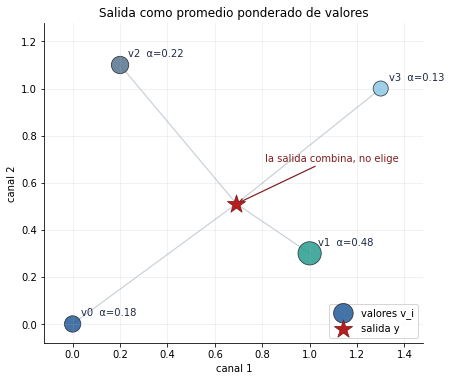

In [2]:
resultado_mezcla = atencion_experimentos.preparar_mezcla_ponderada()

mostrar_tablas_en_columnas(
    [
        ("Formas principales", resultado_mezcla.formas),
        ("Pesos por distribución", resultado_mezcla.pesos),
        ("Salidas y distancias", resultado_mezcla.resumen_casos),
        ("Aportes con softmax", resultado_mezcla.aportes),
    ],
    min_width="360px",
)


Las tablas muestran tres propiedades centrales. Primero, los logits necesitan una normalización: solo después de softmax se obtienen pesos interpretables como distribución. Segundo, los pesos suman uno en los tres casos comparados. Tercero, la salida conserva dos canales porque se mezclan filas de $V$, no los canales entre sí.

El valor con mayor peso no se copia automáticamente en el caso softmax: domina más la mezcla, pero los demás valores siguen aportando mientras sus pesos sean mayores que cero. La distribución concentrada se incluye como contraste didáctico para ver el límite cercano a una selección dura, sin abandonar la lectura de mezcla.

## Visualización de la mezcla

La gráfica ubica los valores en un espacio de dos canales. El tamaño de cada punto representa su peso bajo softmax y la estrella roja representa la salida. Las líneas grises ayudan a recordar que la salida depende de todos los valores ponderados, no de una única selección discreta.

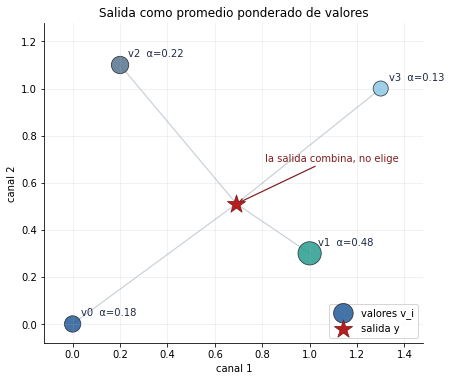

In [3]:
display(resultado_mezcla.figura)
plt.close(resultado_mezcla.figura)


La visualización es deliberadamente pequeña. Su valor no está en sugerir una geometría semántica real, sino en hacer observable que una mezcla ponderada cae dentro de la región inducida por los valores cuando los pesos son no negativos y suman uno. Si un peso domina, la estrella se acerca a ese valor; si los pesos se reparten, la estrella se mueve hacia una zona intermedia.

## Explorador interactivo

El siguiente explorador permite cambiar los logits y comparar tres modos de pesos: softmax, uniforme y selección de un solo punto. La consigna no es buscar una configuración llamativa, sino observar cómo cambia la salida cuando cambia la distribución de pesos.

Lee el modo `un punto` como un contraste didáctico: muestra el extremo de una selección dura, mientras que softmax mantiene una mezcla diferenciable salvo que la distribución sea extremadamente concentrada.

In [4]:
crear_explorador_mezcla_ponderada()


## Verificación de aprendizaje

Modifica el explorador y responde con evidencia concreta:

1. Cambia un logit para concentrar la distribución en un solo valor. ¿Qué ocurre con la posición de la salida?
2. Compara pesos uniformes contra pesos por softmax. ¿Qué cambia en la tabla de aportes?
3. Verifica que los pesos suman uno y explica por qué esa propiedad permite leer la salida como promedio ponderado.
4. Explica por qué una salida cercana a $v_i$ no significa que el modelo haya “entendido” ese valor, sino que el peso asociado fue dominante.

La respuesta debe citar al menos una fila de la tabla de pesos o una comparación visual de la salida.

## Análisis crítico

Lo observado puede leerse en tres niveles:

1. **Qué ocurrió:** los logits se convirtieron en pesos y esos pesos produjeron una salida como suma ponderada de valores.
2. **Por qué ocurrió:** softmax transforma puntajes arbitrarios en una distribución, y la multiplicación $\alpha^\top V$ agrega los valores de forma diferenciable.
3. **Qué límite tiene la conclusión:** este experimento no explica todavía de dónde salen los logits ni por qué un valor debería ser relevante para otro. Tampoco convierte los pesos de atención en una explicación completa del comportamiento del modelo.

Este límite es importante: la atención como mezcla ponderada es el mecanismo de combinación; el siguiente paso es estudiar cómo el modelo calcula los pesos a partir de la propia secuencia. Una tabla de aportes ayuda a depurar el cálculo, pero no debe confundirse con una explicación humana completa del modelo.

## Síntesis

La cadena operacional del notebook es:

$$
\text{logits} \rightarrow \operatorname{softmax} \rightarrow \alpha \rightarrow V \rightarrow y = \alpha^\top V.
$$

Esta cadena se lee así: partimos de puntajes, los convertimos en pesos normalizados, usamos esos pesos para mezclar valores y obtenemos una representación de salida.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que atención no selecciona necesariamente un único elemento: construye una representación contextual mediante una combinación ponderada de información disponible.
</div>


## Preguntas de discusión

1. ¿Qué representa un peso de atención alto en este experimento y qué no representa?
2. ¿Por qué softmax permite interpretar los pesos como una distribución sobre valores disponibles?
3. ¿Qué cambia experimentalmente cuando los pesos pasan de uniformes a concentrados?
4. ¿Por qué esta formulación todavía no explica cómo el modelo decide qué atender?
5. ¿Cómo se relaciona la mezcla ponderada de este notebook con las formas tensoriales estudiadas en el notebook anterior?


## Continuidad

El siguiente notebook introduce queries, keys y values. Allí los pesos dejarán de ser fijados manualmente: se calcularán comparando una consulta con varias llaves. Esa comparación producirá los logits de atención que aquí usamos como punto de partida.
